# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import scipy.io
import scipy.ndimage

# Functions

In [2]:
def fspecial(size, sigma):
    ax = np.arange(-size/2 + 0.5, size / 2 + 0.5)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2)/ (2 * sigma ** 2))
    return kernel / kernel.sum()

In [3]:
def shrinkageOp(z, lmbd):
    return np.maximum(np.abs(z) - lmbd, 0) * np.sign(z)

In [4]:
def proximal_L1(z, gamma, wt):
    return np.maximum(np.abs(z) - (gamma * wt), 0) * np.sign(z)

In [5]:
def penaltyUpdater(mu, primal_res, dual_res, resid_tol, mu_inc, mu_dec):
    if primal_res > (resid_tol * dual_res):
        mu_out = mu * mu_inc
        mu_update = 1
    elif dual_res > (resid_tol * primal_res):
        mu_out = mu/mu_dec
        mu_update = -1
    else:
        mu_out = mu
        mu_update = 0
    return mu_out, mu_update

# Main Code

In [6]:
H = 3648
W = 5472
# Params
gamm_TV2D = 0.001
gamm_sp = 0.005
mu_V = 1
mu_Z = 1
mu_W = 1
mu_T = 1

color = 1 # RED - 0; GREEN - 1; BLUE - 2

maxIters = 50

resid_tol = 1.5
tau_inc = 1.5
tau_dec = 1.5

params = {'gamm_TV2D' : gamm_TV2D, 
          'mu_Z' : mu_Z, 'mu_W' : mu_W, 'mu_V' : mu_V, 'mu_T' : mu_T,
          'maxIters' : maxIters, 
          'resid_tol' : resid_tol,
          'tau_inc' : tau_inc, 'tau_dec' : tau_dec}

In [7]:
# Get files
frameImg = np.array(h5py.File('./cap/avgCap4.mat', 'r').get('avgCap'))[[0,1,3], : ,:]
# print(frameImg)
frameImg = frameImg.transpose(2,1,0)
Ichs = frameImg[:, :, color]
# print(f"Ichs {Ichs.shape}:\n{Ichs[283,136]}\n")

psfload = h5py.File('./psfs/psfs_save_magfs.mat', 'r')
psfs = np.array(psfload.get('psfs'))
# print(psfs.shape)
psfs = psfs.transpose(3,2,1,0)[:,:,[0,1,3], :]
# print(f"psfs {psfs.shape}:\n{psfs[:15, :15, color, 0]}")

drng = np.array(psfload['drng']).transpose(1,0)
magfs = np.array(psfload['mags']).transpose(1,0)

idx = (drng <= 3) # Light
drng = drng[idx]
psfs = psfs[:, :, :, idx[0, :]]
magfs = magfs[idx[0,:]]

psfs = np.squeeze(psfs[:,:,color,:])
Ny, Nx, Nz = psfs.shape


In [8]:
invZ2 = 1 / (drng ** 2)
invZ2 = Nz*invZ2/(np.sum(invZ2))
wght = np.zeros([1,1,Nz])
wght[:] = invZ2

dpth_scl = 1/magfs
dpth_scl = dpth_scl / np.max(dpth_scl)

dpth_scl_temp = np.zeros([1,1,Nz])
dpth_scl_temp[0,0,:] = dpth_scl[:,0]
dpth_scl = dpth_scl_temp


In [9]:
# # Filter operators 
# fftshift2 = lambda x: np.fft.fftshift(np.fft.fftshift(x,0), 1)
# ifftshift2 = lambda x: np.fft.ifftshift(np.fft.ifftshift(x,0),1)

# Fx2 = lambda x: np.fft.fft2(fftshift2(x).T).T
# FiltX2 = lambda H, x: np.real(ifftshift2(np.fft.ifft2(H * Fx2(x))))

# Fxn = lambda x: np.fft.fftn(np.fft.fftshift(x))
# FiltXn = lambda H, x: np.real(np.fft.ifftshift(np.fft.ifftn(H * Fxn(x))))
fftshift2 = lambda x: np.fft.fftshift(x, axes = (0,1))
ifftshift2 = lambda x: np.fft.ifftshift(x, axes = (0,1))

Fx2 = lambda x: np.fft.fft2(fftshift2(x), axes = (0, 1))
FiltX2 = lambda H, x: np.real(ifftshift2(np.fft.ifft2(H * Fx2(x), axes = (0,1))))

Fxn = lambda x: np.fft.fftn(np.fft.fftshift(x))
FiltXn = lambda H, x: np.real(np.fft.ifftshift(np.fft.ifftn(H * Fxn(x))))


In [10]:
# Process PSFS
py = 5
px = 5
pad2d = lambda x: np.pad(x,((py, py), (px,px)), 'constant') if x.ndim == 2 else np.pad(x,((py, py), (px,px), (0, 0)), 'constant')

# Smooth boundary of psf
w_psfCut = 100
kg = fspecial(w_psfCut, w_psfCut/10)
crpSmth = np.zeros([Ny, Nx])
crpSmth[w_psfCut:Ny-w_psfCut, w_psfCut:Nx-w_psfCut] = 1
crpSmth = scipy.ndimage.convolve(crpSmth, kg, mode = 'constant')

psfs = psfs * crpSmth[:, :, np.newaxis]


In [11]:
# normalized psf with sum valu - mono
sms = np.sum(psfs, axis = (0,1), keepdims = True)
psfs = psfs / sms
psfs = 500 * psfs
psfs = pad2d(psfs)

In [12]:
# Filter in the fourier domain
Hd= Fx2(psfs) * dpth_scl
Hd_conj = np.conj(Hd)

# Forward and adjoing of filter
Hdfor = lambda x: FiltX2(Hd, x)
Hdadj = lambda x: FiltX2(Hd_conj, x)

#H'H in fourier domain
HdtHd = np.abs(Hd * Hd_conj)


In [13]:
# Summation Operator
Sfor = lambda x: np.sum(x, axis = 2)
Sadj = lambda x: np.tile(x[:,:, np.newaxis],[1, 1, Nz])
ss = np.zeros(psfs.shape)
ss[0,0,:] = 1
StS = np.real(np.fft.fftn(ss))

In [14]:
# Gradient function - 2D
## x grad filter
kx = np.zeros(psfs.shape)
kx[0,0,:] = 1
kx[0,1,:] = -1
Kx = np.fft.fft2(kx.T).T

## y grad filter 
ky = np.zeros(psfs.shape)
ky[0,0,:] = 1
ky[1,0,:] = -1
Ky = np.fft.fft2(ky.T).T

In [15]:
# Psi
## Forward gradient
Psi = lambda x: [FiltX2(Kx,x), FiltX2(Ky,x)]
## Adjoint of gradient
PsiT = lambda P1, P2: FiltX2(np.conj(Kx), P1) + FiltX2(np.conj(Ky), P2)

## Psi'Psi in fourier domain
lapl = np.zeros(psfs.shape)
lapl[0,0,:] = 4
lapl[0,1,:] = -1
lapl[1,0,:] = -1
lapl[0,-1,:] = -1
lapl[-1,0,:] = -1
PsiTPsi = np.real(np.fft.fft2(lapl.T).T)

In [16]:
# Process input
b = pad2d(Ichs)
Stb = Sadj(b)



In [17]:
## Initialization
Xt_prv = np.zeros(psfs.shape)

rhoV_prv = 0
rhoZdx_prv, rhoZdy_prv = 0, 0
rhoW_prv = 0
rhoT_prv = 0

fdataFid = []
fregPen = []
fobj = []
fobj_alt = []

primal_res_V = []
dual_res_V = []
primal_res_Z = []
dual_res_Z = []
primal_res_W = []
dual_res_W = []
primal_res_T = []
dual_res_T = []

HX_prv = Hdfor(Xt_prv) 
dx_prv, dy_prv = Psi(Xt_prv)

In [18]:
## Iterate
iteration = 0
while iteration < maxIters:
    
    
    # Primal Update
    vFilt_mult = 1.0  / (StS + mu_V)
    numr = Stb + mu_V * HX_prv + rhoV_prv
    V_nxt = FiltXn(vFilt_mult, numr)

    Zdx_nxt = shrinkageOp(dx_prv + rhoZdx_prv/mu_Z, gamm_TV2D/mu_Z)
    Zdy_nxt = shrinkageOp(dy_prv + rhoZdy_prv/mu_Z, gamm_TV2D/mu_Z)

    W_nxt = np.maximum(Xt_prv + rhoW_prv/mu_W, 0)
    
    # Full sparsity
    T_nxt = proximal_L1(Xt_prv + rhoT_prv/mu_T, gamm_sp/mu_T, wght)

    xFilt_mult = 1.0 /(mu_V * HdtHd + mu_Z * PsiTPsi + mu_W + mu_T)
    # Fx2 = lambda x: np.fft.fft2(fftshift2(x).T).T
    # FiltX2 = lambda H, x: np.real(ifftshift2(np.fft.ifft2(H * Fx2(x))))
    #PsiT = lambda P1, P2: FiltX2(np.conj(Kx), P1) + FiltX2(np.conj(Ky), P2)
    enter = mu_Z * Zdx_nxt - rhoZdx_prv
    enter1 = mu_Z * Zdy_nxt - rhoZdy_prv
    test = PsiT(mu_Z * Zdx_nxt - rhoZdx_prv, mu_Z * Zdy_nxt - rhoZdy_prv)
    test_1 = FiltX2(np.conj(Kx), mu_Z * Zdx_nxt - rhoZdx_prv)
    numr = Hdadj(mu_V * V_nxt - rhoV_prv) + PsiT(mu_Z * Zdx_nxt - rhoZdx_prv, mu_Z * Zdy_nxt - rhoZdy_prv) + mu_W * W_nxt - rhoW_prv + mu_T * T_nxt - rhoT_prv ############### may have error here with psiT
    Xt_nxt = FiltX2(xFilt_mult, numr) ############### error here maybe due to numr or filtX2

    # Next derivatives
    HX_nxt = Hdfor(Xt_nxt)
    dx_nxt, dy_nxt = Psi(Xt_nxt)

    # Dual update
    rpV = HX_nxt - V_nxt
    rhoV_nxt = rhoV_prv + mu_V * rpV

    rpZdx = dx_nxt - Zdx_nxt
    rpZdy = dy_nxt - Zdy_nxt
    rhoZdx_nxt = rhoZdx_prv + mu_Z * rpZdx
    rhoZdy_nxt = rhoZdy_prv + mu_Z * rpZdy

    rpW = Xt_nxt - W_nxt
    rhoW_nxt = rhoW_prv + mu_W*rpW

    rpT = Xt_nxt - T_nxt
    rhoT_nxt = rhoT_prv + mu_T * rpT

    # Objective fn value
    penSparse = lambda x: np.sum(np.squeeze(np.sum(np.abs(x), axis = (0, 1))) * wght)

    fdataFid.append(0.5 * (np.linalg.norm(b - Sfor(HX_nxt), 'fro'))**2)
    fregPen.append(gamm_sp * penSparse(Xt_nxt) + gamm_TV2D * (np.sum(np.abs(dx_nxt[:])) + np.sum(np.abs(dy_nxt[:]))))
    fobj.append(fdataFid[iteration] + fregPen[iteration])
    fobj_alt.append(0.5 * (np.linalg.norm(b - Sfor(V_nxt), 'fro') ** 2) + gamm_sp * penSparse(T_nxt) + gamm_TV2D * ( np.sum(np.abs(Zdx_nxt[:])) + np.sum(np.abs(Zdy_nxt[:])) ))

    # Residuals
    primal_res_V.append(np.linalg.norm(rpV))
    dual_res_V.append(mu_V * np.linalg.norm(HX_nxt[:] - HX_prv[:]))

    primal_res_Z.append(np.sqrt(np.linalg.norm(rpZdx[:]) ** 2 + np.linalg.norm(rpZdy[:])** 2) )
    dual_res_Z.append( mu_Z*np.sqrt( np.linalg.norm(dx_nxt[:] - dx_prv[:])**2 + np.linalg.norm(dy_nxt[:] - dy_prv[:])**2 ) )

    primal_res_W.append( np.linalg.norm(rpW[:]) )
    dual_res_W.append( mu_W * np.linalg.norm(Xt_nxt[:] - Xt_prv[:]) )

    primal_res_T.append( np.linalg.norm(rpT[:]) )
    dual_res_T.append( mu_T * np.linalg.norm(Xt_nxt[:] - Xt_prv[:]) )

    # Update mu (augmented penalties)
    mu_V, muV_update = penaltyUpdater(mu_V, primal_res_V[iteration], dual_res_V[iteration], resid_tol, tau_inc, tau_dec)
    mu_Z, muZ_update = penaltyUpdater(mu_Z, primal_res_Z[iteration], dual_res_Z[iteration], resid_tol, tau_inc, tau_dec)
    mu_W, muW_update = penaltyUpdater(mu_W, primal_res_W[iteration], dual_res_W[iteration], resid_tol, tau_inc, tau_dec)
    mu_T, muT_update = penaltyUpdater(mu_T, primal_res_T[iteration], dual_res_T[iteration], resid_tol, tau_inc, tau_dec)

    # print(f"mu_V: {mu_V:0.2f}, mu_Z: {mu_Z:0.2f}, mu_W: {mu_W:0.2f}, mu_T: {mu_T:0.2f}")

    ## Update previous estimate as the current one
    Xt_prv = Xt_nxt
    HX_prv = HX_nxt
    dx_prv, dy_prv = dx_nxt, dy_nxt

    rhoV_prv = rhoV_nxt
    rhoZdx_prv, rhoZdy_prv = rhoZdx_nxt, rhoZdy_nxt
    rhoW_prv = rhoW_nxt
    rhoT_prv = rhoT_nxt


    iteration += 1





In [19]:
Xt_nxt_sngl = np.single(Xt_nxt)

In [20]:

maxVal = np.max(Xt_nxt_sngl)
Xt_Stack = Xt_nxt_sngl / maxVal

In [21]:
print(f"Min: {np.min(Xt_Stack)}\tMax: {np.max(Xt_Stack)}")

Min: -0.007920394651591778	Max: 1.0


In [22]:
import matplotlib.animation as animation
from IPython.display import HTML

In [39]:

fig, ax = plt.subplots()
im = ax.imshow(Xt_Stack[:,:, 0], cmap = 'grey', animated = True)
# cbar = plt.colorbar(im, ax = ax)
ax.axis('off')
def update(frame):
    im.set_array(Xt_Stack[:,:, frame])
    return [im]
plt.subplots_adjust(left = 0, right = 1, top = 1, bottom = 0)
ani = animation.FuncAnimation(fig, update, frames = Xt_Stack.shape[2], interval = 200, blit = False)
ani.save("./3DRecon.mp4", writer = 'ffmpeg', dpi = 150)
plt.close(fig)


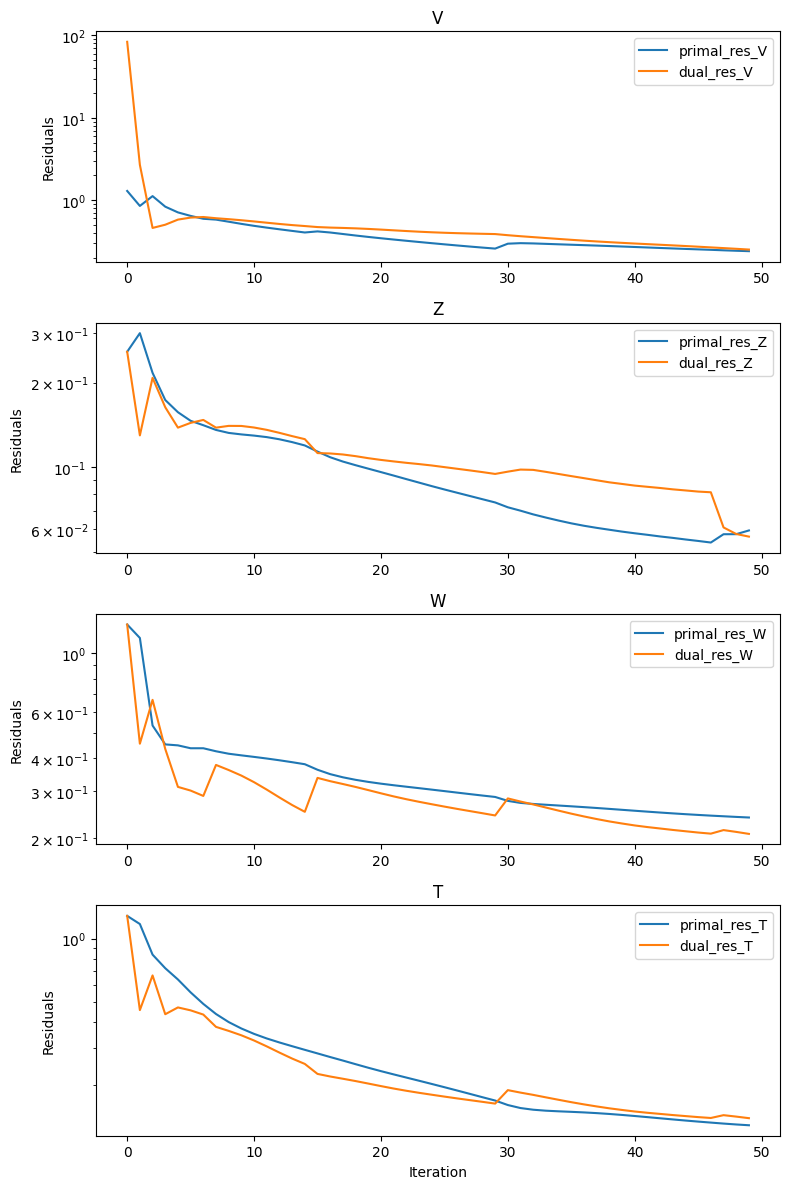

In [41]:
fig1, axes = plt.subplots(4, 1, figsize=(8, 12))  # 4 rows, 1 column
x = np.arange(0, maxIters)
# Subplot 1
axes[0].semilogy(x, primal_res_V, label='primal_res_V')
axes[0].semilogy(x, dual_res_V, label='dual_res_V')
axes[0].set_ylabel('Residuals')
axes[0].legend()
axes[0].set_title('V')

# Subplot 2
axes[1].semilogy(x, primal_res_Z, label='primal_res_Z')
axes[1].semilogy(x, dual_res_Z, label='dual_res_Z')
axes[1].set_ylabel('Residuals')
axes[1].legend()
axes[1].set_title('Z')

# Subplot 3
axes[2].semilogy(x, primal_res_W, label='primal_res_W')
axes[2].semilogy(x, dual_res_W, label='dual_res_W')
axes[2].set_ylabel('Residuals')
axes[2].legend()
axes[2].set_title('W')

# Subplot 4
axes[3].semilogy(x, primal_res_T, label='primal_res_T')
axes[3].semilogy(x, dual_res_T, label='dual_res_T')
axes[3].set_xlabel('Iteration')
axes[3].set_ylabel('Residuals')
axes[3].legend()
axes[3].set_title('T')

plt.tight_layout()
plt.show()


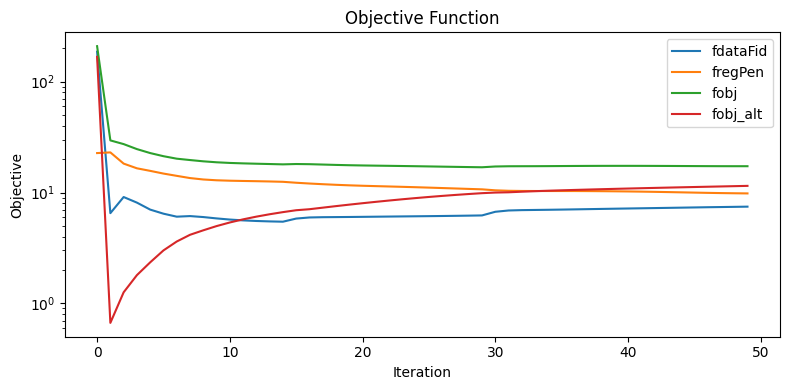

In [42]:
fig2, ax2 = plt.subplots(figsize=(8, 4))

ax2.semilogy(x, fdataFid, label='fdataFid')
ax2.semilogy(x, fregPen, label='fregPen')
ax2.semilogy(x, fobj, label='fobj')
ax2.semilogy(x, fobj_alt, label='fobj_alt')

ax2.set_xlabel('Iteration')
ax2.set_ylabel('Objective')
ax2.set_title('Objective Function')
ax2.legend()

plt.tight_layout()
plt.show()
